### 多次元ガウス分布

２次元ガウス分布の当てはめ

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

data = pd.read_csv('sensor_data/sensor_data_700.txt', delimiter=" ", header=None, names=("date", "time", "ir", "lidar"))
data

,date,time,ir,lidar
0,20180205,84535,16,734
1,20180205,84538,17,736
2,20180205,84541,6,733
3,20180205,84544,17,738
4,20180205,84547,16,734
...,...,...,...,...
86185,20180208,95056,30,746
86186,20180208,95059,20,739
86187,20180208,95102,9,744
86188,20180208,95104,18,741


In [4]:
# 12時から16時までのデータだけを抽出
d = data[(data['time'] < 160000) & (data['time'] >= 120000)]
d = d.loc[:, ['ir', 'lidar']]
d

,ir,lidar
3832,17,726
3833,14,730
3834,14,724
3835,21,724
3836,26,725
...,...,...
65155,8,729
65156,25,730
65157,10,731
65158,15,735


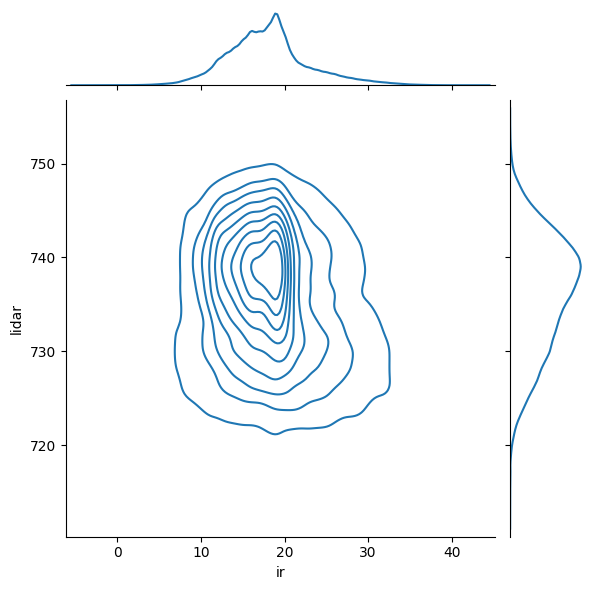

In [9]:
sns.jointplot(data=data, x=data['ir'], y=data['lidar'], kind='kde') # 2次元のカーネル密度推定
plt.show()

分散・共分散・精度

In [10]:
print("光センサの計測値の分散", d.ir.var())
print("Lidarの計測値の分散", d.lidar.var())

# 平均からの距離
diff_ir = d.ir - d.ir.mean()
diff_lidar = d.lidar - d.lidar.mean()
print("diff_ir", diff_ir)
print("diff_lidar", diff_lidar)

光センサの計測値の分散 42.117126367701594
Lidarの計測値の分散 17.702026469211457
diff_ir 3832     -2.860247
3833     -5.860247
3834     -5.860247
3835      1.139753
3836      6.139753
           ...    
65155   -11.860247
65156     5.139753
65157    -9.860247
65158    -4.860247
65159    -0.860247
Name: ir, Length: 14175, dtype: float64
diff_lidar 3832    -3.311958
3833     0.688042
3834    -5.311958
3835    -5.311958
3836    -4.311958
           ...   
65155   -0.311958
65156    0.688042
65157    1.688042
65158    5.688042
65159    3.688042
Name: lidar, Length: 14175, dtype: float64


In [11]:
a = diff_ir * diff_lidar
print("共分散 ", sum(a) / (len(d)-1))

共分散  -0.31677803385437114


In [12]:
d.mean()

ir        19.860247
lidar    729.311958
dtype: float64

Pandasから一発で共分散を取得

In [14]:
d.cov() # 分散共分散行列

,ir,lidar
ir,42.117126,-0.316778
lidar,-0.316778,17.702026
